# Real Audio Curation (Self-Contained)

This notebook performs production-style audio curation without relying
on NeMo Curator tutorial scripts.

Pipeline:
1. Load a public audio dataset (Hugging Face)
2. Run NeMo ASR inference (GPU)
3. Compute WER
4. Compute audio duration
5. Filter by quality
6. Deduplicate by text
7. Save curated JSONL










In [3]:
!nvidia-smi


Mon Jan 19 10:01:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.86.15              Driver Version: 570.86.15      CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 NVL                On  |   00000001:00:00.0 Off |                    0 |
| N/A   36C    P0             62W /  400W |       1MiB /  95830MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Install dependencies 


In [17]:
!pip install -q datasets jiwer soundfile nemo_toolkit[asr]







[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip


## Configuration



In [1]:
# Dataset
HF_DATASET = "librispeech_asr"
HF_CONFIG = "clean"
HF_SPLIT = "validation"

# ASR model
ASR_MODEL = "nvidia/stt_en_conformer_ctc_large"

# Filters
WER_THRESHOLD = 0.5        # 0.0–1.0
MIN_DURATION = 1.0         # seconds
MAX_DURATION = 15.0        # seconds

# Output
OUTPUT_JSONL = "curated_audio.jsonl"




## Load dataset



In [2]:
from datasets import load_dataset

dataset = load_dataset(
    HF_DATASET,
    HF_CONFIG,
    split=HF_SPLIT
)

print("Dataset size:", len(dataset))
dataset[0]


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

0000.parquet:   0%|          | 0.00/350M [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/470M [00:00<?, ?B/s]

...

Generating train.100 split:   0%|          | 0/28539 [00:00<?, ? examples/s]

Generating train.360 split:   0%|          | 0/104014 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2703 [00:00<?, ? examples/s]

Dataset size: 2703


{'file': '/home/albert/.cache/huggingface/datasets/downloads/extracted/234bf103726646f6948bab918be3a226316832f62b2ca6861100cff043922b4a/2277-149896-0000.flac',
 'audio': {'path': '2277-149896-0000.flac',
  'array': array([ 0.00186157,  0.0005188 ,  0.00024414, ..., -0.00097656,
         -0.00109863, -0.00146484]),
  'sampling_rate': 16000},
 'text': "HE WAS IN A FEVERED STATE OF MIND OWING TO THE BLIGHT HIS WIFE'S ACTION THREATENED TO CAST UPON HIS ENTIRE FUTURE",
 'speaker_id': 2277,
 'chapter_id': 149896,
 'id': '2277-149896-0000'}

## Load NeMo ASR model (GPU)

In [3]:
import nemo.collections.asr as nemo_asr

asr_model = nemo_asr.models.EncDecCTCModel.from_pretrained(
    ASR_MODEL
)

asr_model.eval()







stt_en_conformer_ctc_large.nemo:   0%|          | 0.00/451M [00:00<?, ?B/s]

[NeMo I 2026-01-19 10:43:43 mixins:176] Tokenizer SentencePieceTokenizer initialized with 128 tokens


[NeMo W 2026-01-19 10:43:43 modelPT:176] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    manifest_filepath: /data/NeMo_ASR_SET/English/v2.0/train/tarred_audio_manifest.json
    sample_rate: 16000
    batch_size: 32
    shuffle: true
    num_workers: 8
    pin_memory: true
    use_start_end_token: false
    trim_silence: false
    max_duration: 20.0
    min_duration: 0.1
    shuffle_n: 2048
    is_tarred: true
    tarred_audio_filepaths: /data/NeMo_ASR_SET/English/v2.0/train/audio__OP_0..4095_CL_.tar
    
[NeMo W 2026-01-19 10:43:43 modelPT:183] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid configuration file to setup the validation data loader(s). 
    Validation config : 
    manifest_filepath:
    - /data/ASR/LibriSpeech/librispeech_withs

[NeMo I 2026-01-19 10:43:43 features:305] PADDING: 0
[NeMo I 2026-01-19 10:43:44 save_restore_connector:275] Model EncDecCTCModelBPE was successfully restored from /root/.cache/huggingface/hub/models--nvidia--stt_en_conformer_ctc_large/snapshots/5f18b90411b9fdfc9b52b8caf636f204491afb01/stt_en_conformer_ctc_large.nemo.


EncDecCTCModelBPE(
  (preprocessor): AudioToMelSpectrogramPreprocessor(
    (featurizer): FilterbankFeatures()
  )
  (encoder): ConformerEncoder(
    (pre_encode): ConvSubsampling(
      (out): Linear(in_features=10240, out_features=512, bias=True)
      (conv): Sequential(
        (0): Conv2d(1, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(512, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (3): ReLU(inplace=True)
      )
    )
    (pos_enc): RelPositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (layers): ModuleList(
      (0-17): 18 x ConformerLayer(
        (norm_feed_forward1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (feed_forward1): ConformerFeedForward(
          (linear1): Linear(in_features=512, out_features=2048, bias=True)
          (activation): Swish()
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=2048, 

## Utility functions (WER, duration)


In [4]:
import numpy as np
from jiwer import wer

def audio_duration(audio):
    return len(audio["array"]) / audio["sampling_rate"]

def normalize_text(t):
    return t.lower().strip()



In [6]:
import soundfile as sf
import tempfile
import os

def write_temp_wav(audio_array, sample_rate):
    fd, path = tempfile.mkstemp(suffix=".wav")
    os.close(fd)
    sf.write(path, audio_array, sample_rate)
    return path


## Run ASR + compute metrics

In [7]:
curated = []

for i, sample in enumerate(dataset):
    audio = sample["audio"]
    ref_text = normalize_text(sample["text"])

    # Write temp wav for NeMo
    wav_path = write_temp_wav(
        audio["array"],
        audio["sampling_rate"]
    )

    # ASR inference (NeMo expects file paths)
    pred_text = asr_model.transcribe([wav_path])[0]
    pred_text = normalize_text(pred_text)

    # Metrics
    sample_wer = wer(ref_text, pred_text)
    duration = audio_duration(audio)

    curated.append({
        "audio": wav_path,
        "text": ref_text,
        "pred_text": pred_text,
        "wer": sample_wer,
        "duration": duration,
    })

    # Cleanup temp file
    os.remove(wav_path)

    if i % 50 == 0:
        print(f"Processed {i}")



Transcribing: 100%|██████████| 1/1 [00:00<00:00,  2.30it/s]


Processed 0


Transcribing: 100%|██████████| 1/1 [00:00<00:00, 24.13it/s]


Processed 50


Transcribing: 100%|██████████| 1/1 [00:00<00:00, 26.43it/s]


...

Transcribing: 100%|██████████| 1/1 [00:00<00:00, 25.34it/s]


Processed 2650


Transcribing: 100%|██████████| 1/1 [00:00<00:00, 22.63it/s]


Processed 2700


Transcribing: 100%|██████████| 1/1 [00:00<00:00, 26.87it/s]


## Filter by quality (WER + duration)


In [8]:
filtered = [
    s for s in curated
    if s["wer"] <= WER_THRESHOLD
    and MIN_DURATION <= s["duration"] <= MAX_DURATION
]

print("After quality filtering:", len(filtered))


After quality filtering: 2508


## Deduplication


In [9]:
seen = set()
deduped = []

for s in filtered:
    key = s["text"]
    if key not in seen:
        seen.add(key)
        deduped.append(s)

print("After deduplication:", len(deduped))


After deduplication: 2507


## Save final curated dataset


In [10]:
import json

with open(OUTPUT_JSONL, "w", encoding="utf-8") as f:
    for s in deduped:
        f.write(json.dumps(s, ensure_ascii=False) + "\n")

print("Saved:", OUTPUT_JSONL)


Saved: curated_audio.jsonl


## Inspect final samples


In [11]:
for s in deduped[:3]:
    print(s)


{'audio': '/tmp/tmplx5dmulq.wav', 'text': "he was in a fevered state of mind owing to the blight his wife's action threatened to cast upon his entire future", 'pred_text': "he was in a fevered state of mind owing to the blight his wife's action threatened to cast upon his entire future", 'wer': 0.0, 'duration': 6.59}
{'audio': '/tmp/tmpx8xwjlvu.wav', 'text': 'he would have to pay her the money which she would now regularly demand or there would be trouble it did not matter what he did', 'pred_text': 'he would have to pay her the money which she would now regularly demand or there would be trouble it did not matter what he did', 'wer': 0.0, 'duration': 7.145}
{'audio': '/tmp/tmpiuv66d_e.wav', 'text': 'hurstwood walked the floor mentally arranging the chief points of his situation', 'pred_text': 'hurstwood walked the floor mentally arranging the chief points of his situation', 'wer': 0.0, 'duration': 4.835}


## Visualize waveforms


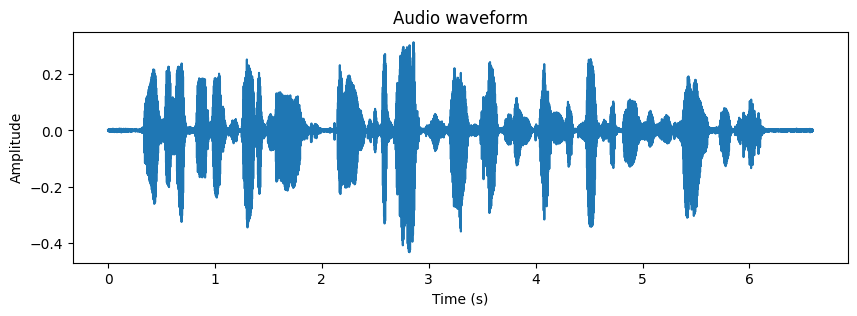

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_waveform(sample):
    audio = sample["audio"]
    array = audio["array"]
    sr = audio["sampling_rate"]
    t = np.linspace(0, len(array) / sr, len(array))

    plt.figure(figsize=(10, 3))
    plt.plot(t, array)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title("Audio waveform")
    plt.show()

plot_waveform(dataset[0])


## Store final audio files


## Create output directory

In [ ]:
FINAL_AUDIO_DIR = "curated_audio_files"
os.makedirs(FINAL_AUDIO_DIR, exist_ok=True)
